### 기본설정

#### 크롬드라이버 설치

 <br>
크롬 버전에 맞춰서 웹브라우저를 다운 받아야 합니다.

크롬 버전 확인하는 방법입니다. 
크롬을 열어준후 설정에서 설치된 크롬의 버전의 확인합니다.

![크롬버전 확인하기1](https://github.com/jeong-wooseok/Python/blob/master/refer/img/img_20201227_5.png?raw=true)

![크롬버전 확인하기2](https://github.com/jeong-wooseok/Python/blob/master/refer/img/img_20201227_6.png?raw=true)

[크롬드라이버다운로드 바로가기](https://chromedriver.chromium.org/downloads)
<br>
소수점 앞의 두자리가 동일한 것으로 다운로드 합니다.

![크롬버전 확인하기2](https://github.com/jeong-wooseok/Python/blob/master/refer/img/img_20201227_7.png?raw=true)
현재 파일 경로를 확인하고, 크롬 드라이버를 넣어줍니다.

#### 기타 기본설정

In [264]:
# colab에서 싷행할 경우
# !pip install -U selenium bs4 requests finance-datareader

# 파일 저장 폴더생성
import os
PROJECT_ROOT_DIR = "./fdr_output"
CHAPTER_ID = "stock_check"
SAMPLES_PATH = os.path.join(PROJECT_ROOT_DIR, "samples", CHAPTER_ID)
os.makedirs(SAMPLES_PATH, exist_ok=True)

#파일 경로 생성함수
def mkfile(file): 
    file = os.path.join(SAMPLES_PATH,f'{file}.xlsx')
    return file

sample_o = os.path.join(SAMPLES_PATH,'sample.xlsx')
test = os.path.join(SAMPLES_PATH,'test.xlsx')
sample_modi = os.path.join(SAMPLES_PATH,'sample_modi.xlsx')
sample_modi1 = os.path.join(SAMPLES_PATH,'sample_modi1.xlsx')

# 결측치제거 및 scaling
def scale(df):
    from sklearn.preprocessing import MinMaxScaler
    import pandas as pd
    df = df.fillna(method='pad').dropna(axis=0)
    scaler = MinMaxScaler()
    scaler.fit(df)
    output = scaler.transform(df)
    output = pd.DataFrame(output, columns=df.columns, index=df.index.values)
    return output
    
# 시각화
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

mpl.rcParams['axes.unicode_minus'] = False
path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=path, size=50).get_name()
plt.rc('font', family=font_name)

plt.rcParams["axes.grid"] = True
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["axes.formatter.limits"] = -10000, 10000
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# 불필요한 경고 무시
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### 크롤링을 통해 ETF 데이터 가져오기

파이썬의 라이브러리인 셀레니움을 사용하여 크롤링을 진행합니다. 
한국예탁결제원의 증권정보포탈 사이트를 참조합니다. <br> 
(한번 다운로드 받으면 저장되니, 자주 실행하지 마세요)

In [10]:
'''Terminal에서 라이브러리 설치하기:
pip install -U selenium bs4 pandas requests finance-datareader matplotlib '''
from selenium import webdriver
from bs4 import BeautifulSoup
import time
import pandas as pd
import os

try:
    # 홈페이지에 접근하여 ETF 항목 클릭
    driver=webdriver.Chrome("./chromedriver.exe")
    driver.get("http://seibro.or.kr/websquare/control.jsp?w2xPath=/IPORTAL/user/etf/BIP_CNTS06025V.xml&menuNo=174")
    time.sleep(5)
    a=driver.find_element_by_xpath('//*[@id="image10"]')
    a.click()
    path = 'ETF.txt'
    if os.path.exists(path):os.remove(path)

    # 페이지 넘김
    i=1
    while True: 
        time.sleep(1)
        a=driver.find_element_by_xpath('//*[@id="pageList1_page_%d"]'%i)
        a.click()

        time.sleep(2)
        html=driver.page_source
        soup=BeautifulSoup(html,"html.parser")

        f = open("ETF.txt", 'a')
        for anchors in soup.select("#grid1_body_tbody")[0]:
            for anchor in anchors.select("td"):
                data = anchor.get_text()+'\n'
                f.write(data)
        f.close()
        i+=1
# 더이상 읽을 페이지 없을 때, 
except:
     
    print('수집이 끝났습니다')

KeyError: '총보수'

In [73]:
# df 생성
etf = mkfile('etf') 

df = pd.DataFrame()
cols = ['종목명','코드','유형','순자산','종가','거래량','수익율','총보수','운용사']
lines = [1,2,3,4,5,6,9,15,16]

with open('ETF.txt','r') as f:
    data = f.readlines()
    
    for idx in range(len(cols)):
        df[cols[idx]] = [j.replace('\n','') for i, j in enumerate(data) if i % 17 == lines[idx]]
    
# 전처리 : 보수, 수익율 없는 상품 제거
df = df.drop(df[df['총보수']==''].index)
df = df.drop(df[df['수익율']==''].index)

# 전처리 : 계산 가능타입으로 변환
for j in cols[3:6]:
    df[j] = df[j].apply(lambda x: x.replace(',',''))
    df[j] = df[j].astype(int)
for j in cols[6:8]:
    df[j] = df[j].astype(float)

df.to_csv(etf,sep=',',encoding='euc-kr')

print(f'추출한 총 ETF의 수 {len(df)}개')

추출한 총 ETF의 수 459개


### 파생상품 제외한 목록 만들기 (연금계좌 활용)

#### ETF : 3개월 수익율 순위

In [75]:
df.sort_values('수익율',ascending =False)[:40]

,종목명,코드,유형,순자산,종가,거래량,수익율,총보수,운용사
107,TIGER 200IT레버리지,243880,파생상품/레버리지,564,74660,24085,126.79,0.69,미래에셋자산운용
259,TIGER 200에너지화학레버리지,243890,파생상품/레버리지,133,24205,34820,97.11,0.69,미래에셋자산운용
155,TIGER 레버리지,123320,파생상품/레버리지,298,27000,782450,86.08,0.09,미래에셋자산운용
104,HANARO 200선물레버리지,304780,파생상품/레버리지,593,31175,13901,86.01,0.45,엔에이치아문디자산운용
5,KODEX 레버리지,122630,파생상품/레버리지,17968,28660,61361853,85.92,0.64,삼성자산운용
262,ARIRANG 200선물레버리지,253150,파생상품/레버리지,129,51600,9814,85.91,0.06,한화자산운용
160,KOSEF 200선물레버리지,253250,파생상품/레버리지,283,25640,26049,85.66,0.46,키움투자자산운용
65,TIGER 200선물레버리지,267770,파생상품/레버리지,1247,21455,3100938,85.36,0.09,미래에셋자산운용
253,KINDEX 레버리지,152500,파생상품/레버리지,136,11260,112431,85.35,0.30,한국투자신탁운용
137,KBSTAR 200선물레버리지,252400,파생상품/레버리지,365,25980,69907,85.11,0.60,케이비자산운용


#### 종목명, 유형 등 조회

In [76]:
df1[df1.종목명.str.contains('TIGER 구리')]

,종목명,코드,유형,순자산,종가,거래량,수익율,총보수,운용사
308,TIGER 구리실물,160580,상품/금속,100,8230,5535,14.15,0.85,미래에셋자산운용


In [158]:
df1.유형.unique()

array(['시장지수/코스피200', '채권/단기자금', '시장지수/MSCI Korea Index', '그룹주/삼성',
       '채권/회사채권', '해외지수/해외지수', '테마/우량주', '테마/기타', '시장지수/코스닥', '섹터/IT',
       '상품/원유', '스타일/스타일', '상품/금속', '채권/국공채권', '섹터/금융', '섹터/경기소비재',
       '섹터/의료', '시장지수/KRX300', '테마/SRI', '통화/미국달러', '기타/기타', '상품/농산물',
       '그룹주/현대차', '투자전략/투자전략', '섹터/산업재', '섹터/소재', '시장지수/코스피50',
       '섹터/필수소비재', '시장지수/코스피100', '시장지수/KRX100', '그룹주/LG', '그룹주/기타',
       '통화/기타통화', '섹터/통신서비스'], dtype=object)

In [77]:
df1[df1.유형.str.contains('상품')]

,종목명,코드,유형,순자산,종가,거래량,수익율,총보수,운용사
30,KODEX WTI원유선물(H),261220,상품/원유,4241,7690,2608820,23.73,0.35,삼성자산운용
40,KODEX 골드선물(H),132030,상품/금속,2465,13090,331722,0.42,0.68,삼성자산운용
62,KODEX 은선물(H),144600,상품/금속,1394,5635,1074015,12.03,0.68,삼성자산운용
73,TIGER 원유선물Enhanced(H),130680,상품/원유,1097,2310,1349300,17.56,0.70,미래에셋자산운용
116,TIGER 농산물선물Enhanced(H),137610,상품/농산물,466,5460,85337,17.93,0.70,미래에셋자산운용
200,TIGER 골드선물(H),319640,상품/금속,195,13915,19632,0.32,0.39,미래에셋자산운용
228,KODEX 구리선물(H),138910,상품/금속,158,6910,35933,21.87,0.68,삼성자산운용
245,KODEX 3대농산물선물(H),271060,상품/농산물,141,9710,26411,20.02,0.55,삼성자산운용
308,TIGER 구리실물,160580,상품/금속,100,8230,5535,14.15,0.85,미래에셋자산운용
329,KODEX 콩선물(H),138920,상품/농산물,90,11265,11858,27.72,0.68,삼성자산운용


#### 연금용 ETF : 3개월 수익율 순위

In [78]:
a = '파생상품'
df1 = df[~df['유형'].str.contains(a)]
# print(df['유형'].unique())
# print()
# print(df1['유형'].unique())

# etf_연금 = mkfile('etf_연금') 
# df1.to_csv(etf_연금,sep=',',encoding='euc-kr')
df1.sort_values('수익율',ascending =False)[:30]

,종목명,코드,유형,순자산,종가,거래량,수익율,총보수,운용사
31,TIGER KRX2차전지K-뉴딜,364980,테마/기타,4232,17355,976809,60.47,0.40,미래에셋자산운용
21,KODEX 2차전지산업,305720,테마/기타,5244,19035,2350016,54.25,0.45,삼성자산운용
24,TIGER 200 IT,139260,섹터/IT,4808,40575,594074,51.71,0.40,미래에셋자산운용
237,KODEX 200IT TR,363580,섹터/IT,152,15155,3981,51.02,0.15,삼성자산운용
210,KBSTAR 200IT,285000,섹터/IT,178,18025,6361,50.65,0.19,케이비자산운용
127,TIGER 현대차그룹+펀더멘털,138540,그룹주/현대차,401,26705,70434,46.49,0.15,미래에셋자산운용
29,TIGER 2차전지테마,305540,테마/기타,4387,17100,1417286,45.04,0.50,미래에셋자산운용
461,ARIRANG KRX300IT,309170,시장지수/KRX300,29,20680,1337,44.87,0.40,한화자산운용
130,KODEX IT,266370,섹터/IT,380,22335,40864,44.80,0.45,삼성자산운용
58,KODEX 자동차,091180,섹터/경기소비재,1539,23500,373100,44.57,0.45,삼성자산운용


### 금일 ETF 수익율 순위 확인

In [126]:
import requests
import json
from pandas import json_normalize
url = 'https://finance.naver.com/api/sise/etfItemList.nhn'
json_data = json.loads(requests.get(url).text)
df2 = json_normalize(json_data['result']['etfItemList'])
df2.sort_values('changeRate',ascending=False)[:10]
df2.columns = ['code','TabCode','이름','현재가','등/락','가격변동','일수익율','일평균가','3개월수익율','거래량/일','거래금액/일,백만','marketSum']
df2 = df2.fillna(0)
df2['3개월수익율'] = df2['3개월수익율'].round(1)
df3 = df2[['code','일수익율','가격변동','거래금액/일,백만']]
df2.sort_values('일수익율',ascending=False)[:40]
# df.to_excel('etf_list.xlsx',header=True,index=False);

,code,TabCode,이름,현재가,등/락,가격변동,일수익율,일평균가,3개월수익율,거래량/일,"거래금액/일,백만",marketSum
431,290080,2,KBSTAR 200고배당커버드콜ATM,6915,2,230,3.44,6875.0,-7.0,238,1,48
117,228810,2,TIGER 미디어컨텐츠,6270,2,195,3.21,6299.0,3.4,571220,3553,470
170,252420,3,KBSTAR 200선물인버스2X,2075,2,50,2.47,2076.0,-49.3,1132424,2336,266
217,228800,2,TIGER 여행레저,4480,2,100,2.28,4477.0,12.7,282408,1257,172
46,168580,4,KINDEX 중국본토CSI300,32715,2,710,2.22,0.0,14.4,11789,382,2094
78,252710,3,TIGER 200선물인버스2X,2145,2,45,2.14,2147.0,-49.1,12501066,26738,1040
98,219390,4,KBSTAR 미국S&P원유생산기업(합성 H),2930,2,60,2.09,0.0,41.4,269124,787,649
55,204480,4,TIGER 차이나CSI300레버리지(합성),35295,2,690,1.99,0.0,36.0,1970974,68960,1659
4,252670,3,KODEX 200선물인버스2X,2075,2,40,1.97,2076.0,-48.9,310269624,640822,17822
383,253230,3,KOSEF 200선물인버스2X,2080,2,40,1.96,2083.0,-48.7,192965,399,69


In [257]:
def price_plot(codes,period):
    from datetime import datetime,timedelta
    for code in codes:
        df = pd.read_csv(etf, encoding = 'euckr', index_col=0)
        df['코드'] = df['코드'].astype(str)
        temp = [i for i in df[df['코드'].apply(lambda x: len(x))<=5].index]
        df.loc[temp,'코드'] = '0'+ df.loc[temp,'코드'].astype(str)
        e_date = datetime.now()
        s_date = e_date - timedelta(int(period))
        df_temp = fdr.DataReader(code, s_date ,e_date)
        name = df[df.코드 == code].종목명.values[0]
        df_kospi = fdr.DataReader('KS11', s_date ,e_date)
        df_temp['p_index'] = df_temp['Close'].apply(lambda x: x/df_temp.iloc[0,3])
        df_temp['p_index'].plot(legend = 'a',label= name, figsize=(16,8))
        df_kospi['p_index'] = df_kospi['Close'].apply(lambda x: x/df_kospi.iloc[0,3])
        df_kospi['p_index'].plot(legend = 'a',label= 'KOSPI지수', figsize=fig)
        
# 다중 차트 만드는 함수  
def price_plot_s(codes,period,row,col, fig = (16,8)):
    import pandas as pd
    from datetime import datetime,timedelta
    import matplotlib.pyplot as plt
    for idx, code in enumerate(codes):
        df = pd.read_csv(etf, encoding = 'euckr', index_col=0)
        df['코드'] = df['코드'].astype(str)
        temp = [i for i in df[df['코드'].apply(lambda x: len(x))<=5].index]
        df.loc[temp,'코드'] = '0'+ df.loc[temp,'코드'].astype(str)
        e_date = datetime.now()
        s_date = e_date - timedelta(int(period))
        df_temp = fdr.DataReader(code, s_date ,e_date)
        df_kospi = fdr.DataReader('KS11', s_date ,e_date)
        name = df[df.코드 == code].종목명.values[0]
                
        plt.subplot(row,col,idx+1) # subplot : 도화지를 나눔, 1행/2열로 나누고 첫번째도화지에...
        df_temp['p_index'] = df_temp['Close'].apply(lambda x: x/df_temp.iloc[0,3])
        df_temp['p_index'].plot(legend = 'a',label= name, figsize=fig)
        df_kospi['p_index'] = df_kospi['Close'].apply(lambda x: x/df_kospi.iloc[0,3])
        df_kospi['p_index'].plot(legend = 'a',label= 'KOSPI지수', figsize=fig)

# 코드 리스트로 df 불러오기
def price_codes(codes, period):
    import pandas as pd
    from datetime import datetime,timedelta
    import matplotlib.pyplot as plt
    df = pd.read_csv(etf, encoding = 'euckr', index_col=0)
    df['코드'] = df['코드'].astype(str)
    temp = [i for i in df[df['코드'].apply(lambda x: len(x))<=5].index]
    df.loc[temp,'코드'] = '0'+ df.loc[temp,'코드'].astype(str)

    e_date = datetime.now()
    s_date = e_date - timedelta(int(period))
    
    df_m = pd.DataFrame()
    df_m_index = pd.DataFrame()
    
    for code in codes:
        df_temp = fdr.DataReader(code, s_date ,e_date)
        name = df[df.코드 == code].종목명.values[0]
        df_temp['p_index'] = df_temp['Close'].apply(lambda x: x/df_temp.iloc[0,3])
        df_m[name] = df_temp['Close']
        df_m_index[name] = df_temp['p_index']
    df_kospi = fdr.DataReader('KS11', s_date ,e_date)
    df_cur = fdr.DataReader('USD/KRW', s_date ,e_date)
    df_kospi['p_index'] = df_kospi['Close'].apply(lambda x: x/df_kospi.iloc[0,3])
    df_cur['p_index'] = df_cur['Close'].apply(lambda x: x/df_cur.iloc[0,3])
    df_m_index['KOSPI'] = df_kospi['p_index'] 
    df_m_index['USD/KRW'] = df_cur['p_index'] 
    
    return df_m, df_m_index  
        
# 특정텍스트 포함 조건식을 걸어서 가격 df를 만드는 함수
def price_texts(유형,종목명, period):
    import pandas as pd
    from datetime import datetime,timedelta
    import matplotlib.pyplot as plt
    df = pd.read_csv(etf, encoding = 'euckr', index_col=0)
    df['코드'] = df['코드'].astype(str)
    temp = [i for i in df[df['코드'].apply(lambda x: len(x))<=5].index]
    df.loc[temp,'코드'] = '0'+ df.loc[temp,'코드'].astype(str)
    
    if 유형 != 'None':
        codes = [code for code in df[df.유형.str.contains(유형)].코드]
        names = [n for n in df[df.유형.str.contains(유형)].종목명]
    elif 종목명 != 'None':
        codes = [code for code in df[df.종목명.str.contains(종목명)].코드]
        names = [n for n in df[df.종목명.str.contains(종목명)].종목명]
    print(f'해당종목은 {names}입니다.')
    e_date = datetime.now()
    s_date = e_date - timedelta(int(period))
    
    df_m = pd.DataFrame()
    df_m_index = pd.DataFrame()
    for code in codes:
        df_temp = fdr.DataReader(code, s_date ,e_date)
        name = df[df.코드 == code].종목명.values[0]
        df_temp['p_index'] = df_temp['Close'].apply(lambda x: x/df_temp.iloc[0,3])
        df_m[name] = df_temp['Close']
        df_m_index[name] = df_temp['p_index']
        
    df_kospi = fdr.DataReader('KS11', s_date ,e_date)
    df_cur = fdr.DataReader('USD/KRW', s_date ,e_date)
    df_kospi['p_index'] = df_kospi['Close'].apply(lambda x: x/df_kospi.iloc[0,3])
    df_cur['p_index'] = df_cur['Close'].apply(lambda x: x/df_cur.iloc[0,3])
    df_m_index['KOSPI'] = df_kospi['p_index'] 
    df_m_index['USD/KRW'] = df_cur['p_index'] 

    return df_m, df_m_index

# 구성종목 확인함수
def comp(codes):
    import requests
    import pandas as pd
    df = pd.read_csv(etf, encoding = 'euckr', index_col=0)
    df['코드'] = df['코드'].astype(str)
    temp = [i for i in df[df['코드'].apply(lambda x: len(x))<=5].index]
    df.loc[temp,'코드'] = '0'+ df.loc[temp,'코드'].astype(str)
    
    df_l = []
    try:
        for idx, code in enumerate(codes):
            name = df[df.코드 == code].종목명.values[0]
            url = f'https://finance.naver.com/item/main.nhn?code={code}'
            html = requests.get(url).text
            dfs = pd.read_html(html)
            dfs_c = dfs[3]
            if dfs[3]['구성비중'][2]!='-':
                dfs_c = dfs_c.dropna()[['구성종목(구성자산)','구성비중','등락률']]
                dfs_c.columns = [name,f'구성비중{idx+1}',f'등락률{idx+1}']
                df_l.append(dfs_c)
        df_m = pd.concat(df_l,axis=1)
    except:
        pass    
        df_m = pd.concat(df_l,axis=1)
    return df_m

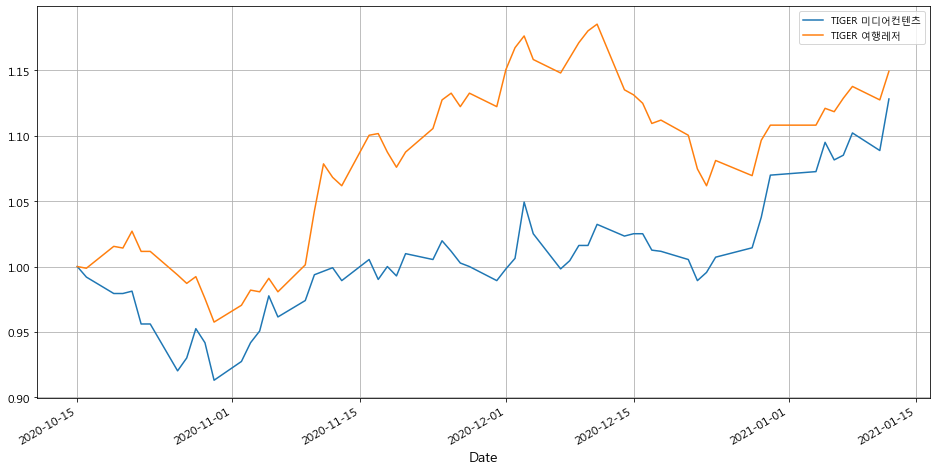

In [154]:
codes =['228810','228800']
price_plot(codes,90)

#### 금일 상위 20개 종목 30일 차트 조회

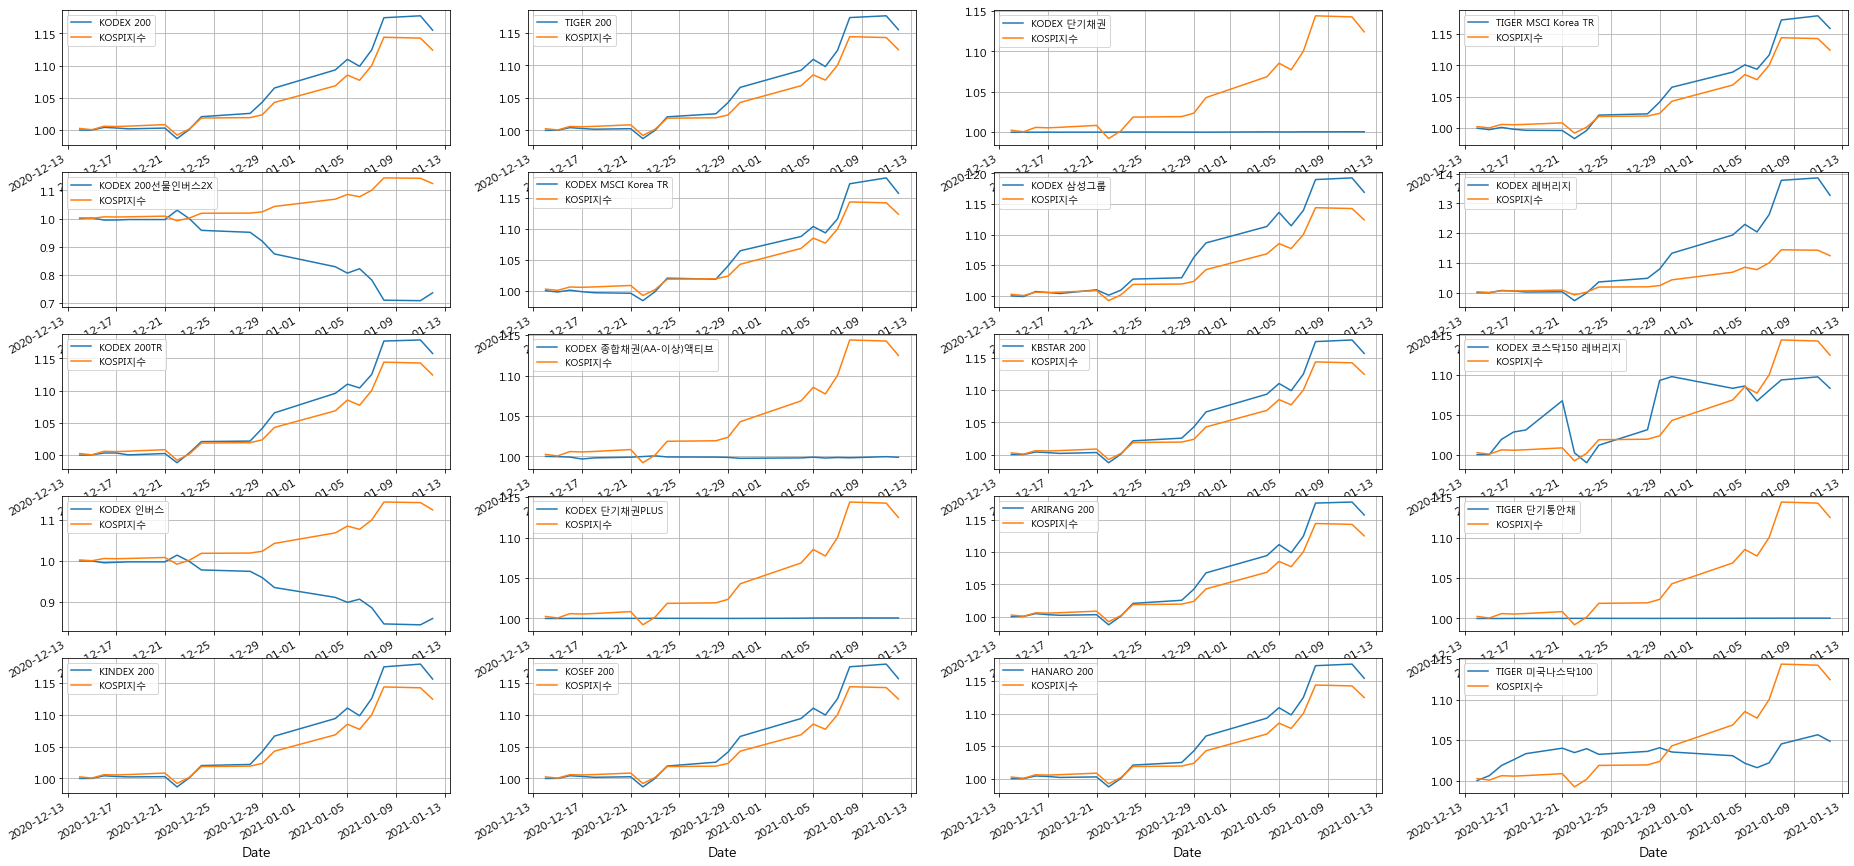

In [167]:
li = [code for code in df2.code[:20]]
price_plot_s(li,30,5,4,(32,16)) # (리스트, 일자,행,열,차트크기)

#### 관심종목 30일 차트 조회

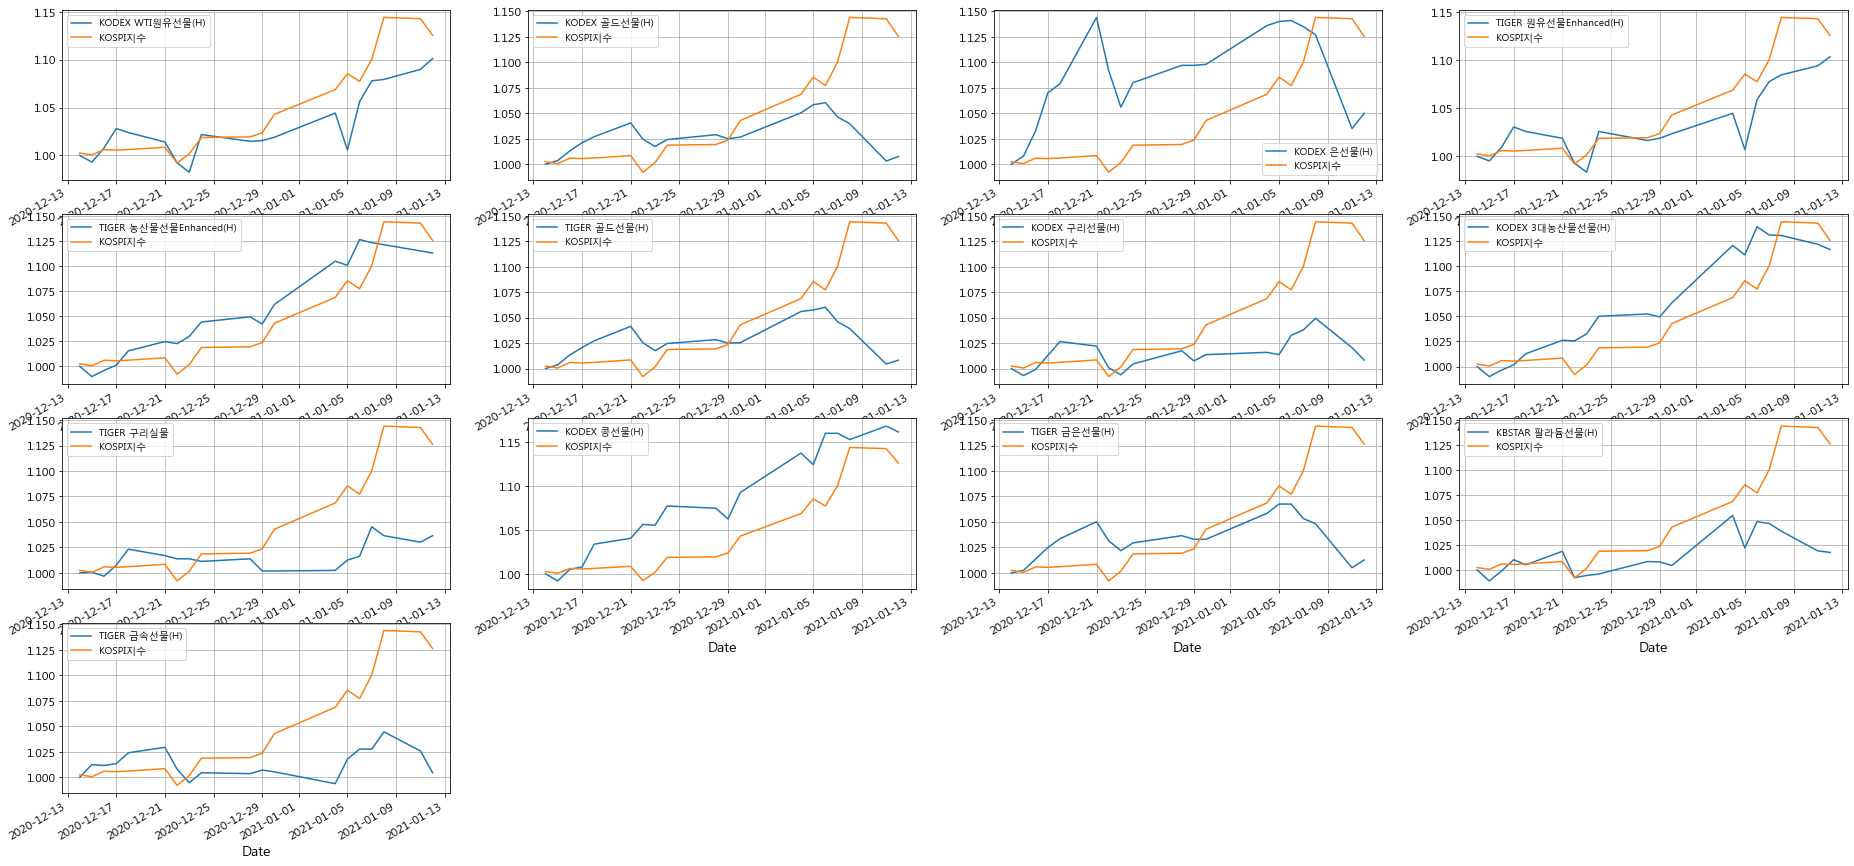

In [168]:
li = [code for code in df1[df1.유형.str.contains('상품')].코드]
price_plot_s(li,30,4,4,(32,16))

#### 관심 종목 corr구하기 (kospi 비교)

In [198]:
df = price_texts('None','골드',20)[1]
df.corr()

해당종목은 ['KODEX 골드선물(H)', 'KINDEX 골드선물 레버리지(합성 H)', 'TIGER 골드선물(H)', 'KODEX 골드선물인버스(H)']입니다.


,KODEX 골드선물(H),KINDEX 골드선물 레버리지(합성 H),TIGER 골드선물(H),KODEX 골드선물인버스(H),KOSPI,USD/KRW
KODEX 골드선물(H),1.000000,0.997207,0.995138,-0.995663,-0.091680,-0.719158
KINDEX 골드선물 레버리지(합성 H),0.997207,1.000000,0.991869,-0.991374,-0.110353,-0.726562
TIGER 골드선물(H),0.995138,0.991869,1.000000,-0.991177,-0.082051,-0.723606
KODEX 골드선물인버스(H),-0.995663,-0.991374,-0.991177,1.000000,0.085097,0.712533
KOSPI,-0.091680,-0.110353,-0.082051,0.085097,1.000000,0.105469
USD/KRW,-0.719158,-0.726562,-0.723606,0.712533,0.105469,1.000000


In [195]:
li = [code for code in df2.code[:20]]
df_t = price_codes(li,30)
df_t[1].tail(5)

,KODEX 200,TIGER 200,KODEX 단기채권,TIGER MSCI Korea TR,KODEX 200선물인버스2X,KODEX MSCI Korea TR,KODEX 삼성그룹,KODEX 레버리지,KODEX 200TR,KODEX 종합채권(AA-이상)액티브,KBSTAR 200,KODEX 코스닥150 레버리지,KODEX 인버스,KODEX 단기채권PLUS,ARIRANG 200,TIGER 단기통안채,KINDEX 200,KOSEF 200,HANARO 200,TIGER 미국나스닥100
Date,,,,,,,,,,,,,,,,,,,,
2021-01-06,1.098975,1.098045,1.000390,1.093915,0.822300,1.093854,1.114458,1.204087,1.104114,0.998003,1.099407,1.067348,0.906593,1.000583,1.098941,1.00035,1.098724,1.099690,1.098087,1.015955
2021-01-07,1.124595,1.123129,1.000536,1.116402,0.782230,1.116694,1.139650,1.262740,1.125105,0.998638,1.125135,1.080753,0.885714,1.000632,1.124413,1.00035,1.125991,1.125286,1.124899,1.021971
2021-01-08,1.174353,1.173432,1.000536,1.172288,0.710801,1.173588,1.190033,1.377885,1.176742,0.998275,1.175647,1.093840,0.846154,1.000681,1.175627,1.00040,1.175688,1.175401,1.173808,1.045293
2021-01-11,1.177319,1.176129,1.000585,1.178902,0.709059,1.183140,1.192771,1.386058,1.178421,0.999682,1.178206,1.097670,0.843956,1.000632,1.177236,1.00045,1.179987,1.179577,1.176233,1.056665
2021-01-12,1.156149,1.155765,1.000634,1.160053,0.735192,1.155731,1.168675,1.331490,1.156591,0.998911,1.156519,1.079796,0.860440,1.000632,1.155919,1.00040,1.157690,1.157483,1.155888,1.049166


#### 구성종목 확인하기

In [263]:
comp(['228810','228800'])

,TIGER 미디어컨텐츠,구성비중1,등락률1,TIGER 여행레저,구성비중2,등락률2
1,CJ CGV,11.62%,+5.74%,파라다이스,9.91%,+1.97%
2,스튜디오드래곤,11.38%,+2.72%,강원랜드,9.66%,+2.53%
3,CJ ENM,10.87%,+2.50%,호텔신라,9.47%,+2.57%
4,JYP Ent.,9.52%,+0.83%,하나투어,9.20%,+2.81%
5,제이콘텐트리,9.20%,+4.73%,한진칼,8.71%,+0.59%
9,에스엠,8.28%,-0.52%,GKL,8.20%,+1.26%
10,와이지엔터테인먼트,8.25%,+1.02%,아난티,8.10%,-0.97%
11,초록뱀,6.25%,+3.35%,롯데관광개발,7.93%,-1.34%
12,키이스트,4.29%,-4.20%,모두투어,5.28%,+3.94%
13,지니뮤직,3.48%,+0.14%,진에어,4.35%,-2.50%


In [262]:
comp([code for code in df1[df1.유형.str.contains('우량주')].코드])

,TIGER TOP10,구성비중1,등락률1,KODEX KTOP30,구성비중2,등락률2,TIGER KTOP30,구성비중3,등락률3,TIGER 우량가치,...,등락률4,KOSEF 블루칩,구성비중5,등락률5,KODEX FnKorea50,구성비중6,등락률6,KBSTAR 우량업종,구성비중7,등락률7
1,삼성전자,25.58%,-2.75%,삼성전자,23.07%,-2.75%,삼성전자,23.08%,-2.75%,한화생명,...,-4.81%,SK이노베이션,3.46%,-5.95%,SK이노베이션,2.74%,-5.95%,LG전자,2.98%,-4.23%
2,SK하이닉스,15.59%,-4.89%,LG화학,10.10%,-5.11%,LG화학,10.14%,-5.11%,현대차,...,-5.42%,LG전자,3.10%,-4.23%,LG전자,2.64%,-4.23%,현대모비스,2.90%,-7.38%
3,LG화학,9.84%,-5.11%,NAVER,7.83%,-4.37%,NAVER,7.85%,-4.37%,CJ,...,-1.93%,현대모비스,3.03%,-7.38%,현대차,2.47%,-5.42%,현대차,2.81%,-5.42%
4,NAVER,8.59%,-4.37%,삼성SDI,7.39%,-2.47%,삼성SDI,7.42%,-2.47%,이마트,...,+4.03%,현대차,2.97%,-5.42%,LG,2.41%,-1.94%,LG,2.72%,-1.94%
5,셀트리온,8.48%,-0.27%,카카오,4.59%,-2.43%,카카오,4.60%,-2.43%,효성중공업,...,-4.14%,LG,2.84%,-1.94%,삼성SDI,2.33%,-2.47%,삼성SDI,2.63%,-2.47%
9,현대차,8.19%,-5.42%,유한양행,3.90%,-2.59%,셀트리온,3.80%,-0.27%,현대제철,...,-4.06%,삼성SDI,2.75%,-2.47%,삼성전자,2.21%,-2.75%,삼성전자,2.50%,-2.75%
10,삼성SDI,8.04%,-2.47%,셀트리온,3.86%,-0.27%,유한양행,3.72%,-2.59%,기아차,...,-1.71%,삼성전자,2.64%,-2.75%,LG화학,2.19%,-5.11%,한화솔루션,2.46%,-5.81%
11,카카오,5.98%,-2.43%,현대모비스,3.57%,-7.38%,현대모비스,3.58%,-7.38%,SK렌터카,...,+1.49%,한국전력,2.54%,-1.52%,카카오,2.15%,-2.43%,LG화학,2.43%,-5.11%
12,현대모비스,4.88%,-7.38%,SK이노베이션,2.98%,-5.95%,SK이노베이션,2.99%,-5.95%,효성화학,...,-0.85%,LG디스플레이,2.53%,+1.28%,삼성물산,2.13%,-4.65%,두산퓨얼셀,2.43%,-6.45%
13,엔씨소프트,3.88%,-4.70%,롯데케미칼,2.91%,+6.61%,롯데케미칼,2.92%,+6.61%,현대그린푸드,...,+0.90%,삼성물산,2.51%,-4.65%,SK,2.12%,-5.00%,삼성물산,2.41%,-4.65%


In [ ]:
# 추출 및 수집 : 최초원본 
# from selenium import webdriver
# from bs4 import BeautifulSoup
# import time
# import pandas as pd
# import os

# PROJECT_ROOT_DIR = "./fdr_output"
# CHAPTER_ID = "stock_check"
# SAMPLES_PATH = os.path.join(PROJECT_ROOT_DIR, "samples", CHAPTER_ID)
# os.makedirs(SAMPLES_PATH, exist_ok=True)

# def mkfile(file): #파일 경로 생성함수
#     file = os.path.join(SAMPLES_PATH,f'{file}.csv')
#     return file

# etf = mkfile('etf') 

# try:
#     # 홈페이지에 접근하여 ETF 항목 클릭
#     driver=webdriver.Chrome("./chromedriver.exe")
#     driver.get("http://seibro.or.kr/websquare/control.jsp?w2xPath=/IPORTAL/user/etf/BIP_CNTS06025V.xml&menuNo=174")
#     time.sleep(5)
#     a=driver.find_element_by_xpath('//*[@id="image10"]')
#     a.click()
#     path = 'ETF.txt'
#     if os.path.exists(path):os.remove(path)

#     # 페이지 넘김
#     i=1

#     while True: 
#         time.sleep(1)
#         a=driver.find_element_by_xpath('//*[@id="pageList1_page_%d"]'%i)
#         a.click()

#         time.sleep(2)
#         html=driver.page_source
#         soup=BeautifulSoup(html,"html.parser")

#         f = open("ETF.txt", 'a')
#         for anchors in soup.select("#grid1_body_tbody")[0]:
#             for anchor in anchors.select("td"):
#                 data = anchor.get_text()+'\n'
#                 f.write(data)
#         f.close()
#         i+=1
    
    
# # 더이상 읽을 테이지 없을 때, 
# except:
#     # 리스트화 하여 항목을 담아주고, 딕셔너리로 변환하여, 판다스 DF만들기
#     df = pd.DataFrame()
#     cols = ['종목명','코드','유형','순자산','종가','거래량','수익율','총보수','운용사']
#     종목명 = [] #1;
#     코드 = [] #2
#     유형 = [] #3
#     순자산 =[] #4
#     종가 =[] #5
#     거래량 = [] #6
#     수익율 = [] #9
#     총보수 = [] #15
#     운용사 = [] #16
#     with open('ETF.txt','r') as f:
#         data = f.readlines()
#         for i, j in enumerate(data):
#             if i % 17 == 1:종목명.append(j.replace('\n',''))
#             elif i % 17 ==2:코드.append(j.replace('\n',''))
#             elif i % 17 ==3:유형.append(j.replace('\n',''))
#             elif i % 17 ==4:순자산.append(j.replace('\n',''))
#             elif i % 17 ==5:종가.append(j.replace('\n',''))
#             elif i % 17 ==6:거래량.append(j.replace('\n',''))
#             elif i % 17 ==9:수익율.append(j.replace('\n',''))
#             elif i % 17 ==15:총보수.append(j.replace('\n',''))
#             elif i % 17 ==16:운용사.append(j.replace('\n',''))      
#     data = {'종목명':종목명,'코드':코드,'유형':유형,'순자산':순자산,'종가':종가,'거래량':거래량,'수익율':수익율,'총보수':총보수,'운용사':운용사}
#     df = pd.DataFrame(data, columns = cols)

#     # 보수, 수익율 없는 상품 제거하기
#     df = df.drop(df[df['총보수']==''].index)
#     df = df.drop(df[df['수익율']==''].index)

#     # 전처리 : 계산 가능한 값으로 변환하기
#     df['거래량']=df['거래량'].apply(lambda x: x.replace(',',''))
#     df['종가']=df['종가'].apply(lambda x: x.replace(',',''))
#     df['순자산']=df['순자산'].apply(lambda x: x.replace(',',''))
#     df['거래량']=df['거래량'].astype(int)
#     df['종가']=df['종가'].astype(int)
#     df['순자산']=df['순자산'].astype(int)
#     df['수익율']=df['수익율'].astype(float)
#     df['총보수']=df['총보수'].astype(float)

#     # 전처리 : 5개 자리인 코드를 6개자리로 변환
#     df['코드'] = df['코드'].astype(str)
#     code = [i for i in df[df['코드'].apply(lambda x: len(x))<=5].index]
#     df.loc[code,'코드'] = '0'+ df.loc[code,'코드'].astype(str)

#     df.to_csv(etf,sep=',',encoding='euc-kr')
    
#     print('연산이 끝났습니다')
#     print(f'추출한 총 ETF의 수 {len(df)}개')